In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ticker = 'SPY'
start_date = '2020-01-01'
end_date = '2024-01-01'

data = yf.download(ticker, start=start_date, end=end_date)['Close']

weekly_data = data.resample('W').last()
weekly_returns = weekly_data.pct_change().dropna()

mu = float(weekly_returns.mean().iloc[0]) if isinstance(weekly_returns, pd.DataFrame) else weekly_returns.mean()
sigma = float(weekly_returns.std().iloc[0]) if isinstance(weekly_returns, pd.DataFrame) else weekly_returns.std()
S0 = float(weekly_data.iloc[-1].iloc[0]) if isinstance(weekly_data, pd.DataFrame) else weekly_data.iloc[-1]

C:\Users\pablo\AppData\Local\Temp\ipykernel_18584\2294708926.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


In [3]:
num_simulations = 10000
weeks = 52
capital_total = 5000.0
aporte_semanal = 100.0
semanas_dca = int(capital_total / aporte_semanal) # 50 semanas de aportaciones

np.random.seed(42)
sim_returns = np.random.normal(mu, sigma, (weeks, num_simulations))

price_paths = np.zeros((weeks, num_simulations))
price_paths[0] = S0
for t in range(1, weeks):
    price_paths[t] = price_paths[t-1] * (1 + sim_returns[t])

In [4]:
ls_shares = capital_total / S0
ls_portfolio_values = ls_shares * price_paths # Valor del portafolio cada semana

dca_portfolio_values = np.zeros_like(price_paths)
dca_shares_accumulated = np.zeros(num_simulations)
cash_held = np.full(num_simulations, capital_total) # Efectivo disponible

for t in range(weeks):
    if t < semanas_dca:
        # Se invierten $100 semanales al precio de mercado de esa semana
        shares_bought = aporte_semanal / price_paths[t]
        dca_shares_accumulated += shares_bought
        cash_held -= aporte_semanal
    
    # El valor del portafolio = (Acciones acumuladas * precio actual) + efectivo no invertido
    dca_portfolio_values[t] = (dca_shares_accumulated * price_paths[t]) + cash_held

In [5]:
ls_final = ls_portfolio_values[-1]
dca_final = dca_portfolio_values[-1]

# Inversión Única (LS)
ls_mean = np.mean(ls_final)
ls_std = np.std(ls_final)
ls_prob_loss = np.sum(ls_final < capital_total) / num_simulations

# Inversión Periódica (DCA)
dca_mean = np.mean(dca_final)
dca_std = np.std(dca_final)
dca_prob_loss = np.sum(dca_final < capital_total) / num_simulations

In [6]:
print("\n" + "="*50)
print("RESULTADOS DE LA SIMULACIÓN (Al final del año)")
print("="*50)
print(f"INVERSIÓN ÚNICA (Lump Sum):")
print(f"  Valor Final Promedio: ${ls_mean:,.2f}")
print(f"  Desviación Estándar:  ${ls_std:,.2f}")
print(f"  Prob. de Pérdida:     {ls_prob_loss:.2%}")
print("-" * 50)
print(f"INVERSIÓN PERIÓDICA (DCA):")
print(f"  Valor Final Promedio: ${dca_mean:,.2f}")
print(f"  Desviación Estándar:  ${dca_std:,.2f}")
print(f"  Prob. de Pérdida:     {dca_prob_loss:.2%}")


RESULTADOS DE LA SIMULACIÓN (Al final del año)
INVERSIÓN ÚNICA (Lump Sum):
  Valor Final Promedio: $5,703.21
  Desviación Estándar:  $1,230.97
  Prob. de Pérdida:     30.44%
--------------------------------------------------
INVERSIÓN PERIÓDICA (DCA):
  Valor Final Promedio: $5,353.31
  Desviación Estándar:  $701.42
  Prob. de Pérdida:     32.72%


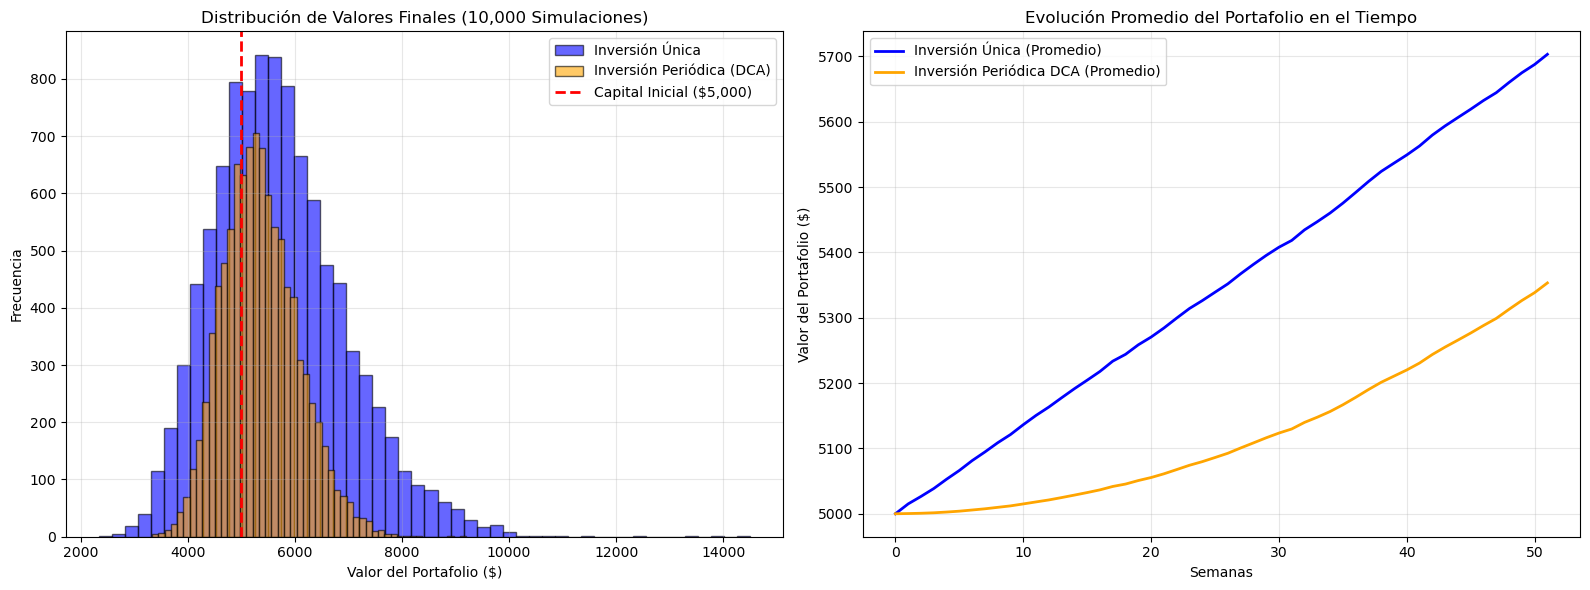

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Histogramas comparativos
axes[0].hist(ls_final, bins=50, alpha=0.6, label='Inversión Única', color='blue', edgecolor='black')
axes[0].hist(dca_final, bins=50, alpha=0.6, label='Inversión Periódica (DCA)', color='orange', edgecolor='black')
axes[0].axvline(capital_total, color='red', linestyle='dashed', linewidth=2, label='Capital Inicial ($5,000)')
axes[0].set_title('Distribución de Valores Finales (10,000 Simulaciones)')
axes[0].set_xlabel('Valor del Portafolio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Evolución Promedio
ls_mean_path = np.mean(ls_portfolio_values, axis=1)
dca_mean_path = np.mean(dca_portfolio_values, axis=1)

axes[1].plot(ls_mean_path, label='Inversión Única (Promedio)', color='blue', linewidth=2)
axes[1].plot(dca_mean_path, label='Inversión Periódica DCA (Promedio)', color='orange', linewidth=2)
axes[1].set_title('Evolución Promedio del Portafolio en el Tiempo')
axes[1].set_xlabel('Semanas')
axes[1].set_ylabel('Valor del Portafolio ($)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Estrategias: Inversión Única vs. DCA

¿En qué condiciones es más ventajosa la inversión periódica?
* Mercados a la baja o de alta volatilidad (Drawdowns): En este escenario puedes comprar a precios cada vez más baratos en vez de ver todas tus inversiones caer
* Aversión al riesgo y protección del capital: Como se observa en los resultados empíricos, el DCA tiene una menor desviación estándar y suele presentar una menor probabilidad de pérdida absoluta del capital. Reduce considerablemente el "riesgo de timing".

¿Cuándo es preferible la inversión en un solo momento?
* Mercados con tendencia alcista sólida: Matemáticamente, los mercados accionarios tienden a subir a largo plazo. La inversión única expone todo tu capital (los $5,000) a este crecimiento desde el día uno, obteniendo interés compuesto sobre una base más grande durante todo el periodo.
* Maximización del Valor Esperado: Como lo demuestra la evolución promedio en la simulación, la inversión única genera, en promedio, un valor final mayor.

**Conclusión:**
Si la prioridad absoluta es maximizar el valor esperado matemáticamente asumiendo que el mercado subirá, la Inversión Única* es mejor. Si la prioridad es mitigar la volatilidad, protegerse contra escenarios extremos de caídas a corto plazo y mantener la disciplina psicológica, el DCA es la estrategia recomendada.